# Daily Raw And Adjusted Equity Prices

Fetching daily equity prices can be accomplished by querying our Nasdaq Data Link subscription.

To do this, you must first obtain your **API Key**

There are two main ways to make queries:

In [3]:
import os
import datetime
import nasdaqdatalink

import plotnine as p9

import pandas as pd
import numpy as np


In [4]:
nasdaqdatalink.ApiConfig.api_key = BrianBoonstraPrivateKeys['Nasdaq']

## Just Some Tickers: Download By Symbol

In [35]:
some_tickers = ['FB', 'META', 'METV', 'GE', 'WULF', 'GM', 'XLE']

In [36]:
some_eqs = nasdaqdatalink.get_table('NDAQ/USEDHADJ', symbol=some_tickers)
print(some_eqs.shape)
some_eqs.dtypes

Fetching URL: https://data.nasdaq.com/api/v3/datatables/NDAQ/USEDHADJ with options: {'params': {'symbol[]': ['FB', 'META', 'METV', 'GE', 'WULF', 'GM', 'XLE']}, 'headers': {'x-api-token': 'xQJNSUnDfncqTKyakafQ', 'accept': 'application/json', 'request-source': 'python', 'request-source-version': '1.0.4'}}
(10000, 17)


date                datetime64[ns]
symbol                      object
symbol_new                  object
composite_figi              object
share_class_figi            object
volume                     float64
low                        float64
high                       float64
open                       float64
close                      float64
volume_adj                 float64
low_adj                    float64
high_adj                   float64
open_adj                   float64
close_adj                  float64
action                      object
value                       object
dtype: object

In [38]:
date_ranges = some_eqs.groupby('symbol')[['date']].aggregate(['min', 'max'])
date_ranges

date           
              min        max
symbol                      
FB     2014-01-02 2026-01-28
GE     2014-01-02 2026-01-26
GM     2014-01-02 2026-01-28
META   2021-06-30 2026-01-27
METV   2022-02-01 2026-01-28
WULF   2021-12-15 2026-01-27
XLE    2014-01-02 2026-01-26

In [39]:
company_names = nasdaqdatalink.get_table('NDAQ/TICKERS', symbol=some_tickers)
company_names

Fetching URL: https://data.nasdaq.com/api/v3/datatables/NDAQ/TICKERS with options: {'params': {'symbol[]': ['FB', 'META', 'METV', 'GE', 'WULF', 'GM', 'XLE']}, 'headers': {'x-api-token': 'xQJNSUnDfncqTKyakafQ', 'accept': 'application/json', 'request-source': 'python', 'request-source-version': '1.0.4'}}


,symbol,exchange,company_name
None,,,
0,META,NASDAQ,META PLATFORMS INC
1,XLE,NYSEARCA,STATE STREET(R) ENERGY SELECT SECTOR SPDR(R) ETF
2,FB,BATS,PROSHARES S&P 500 DYNAMIC BUFFER ETF
3,GM,NYSE,GENERAL MOTORS CO
4,GE,NYSE,GE AEROSPACE
5,METV,NYSEARCA,ROUNDHILL BALL METAVERSE ETF
6,WULF,NASDAQ,TERAWULF INC


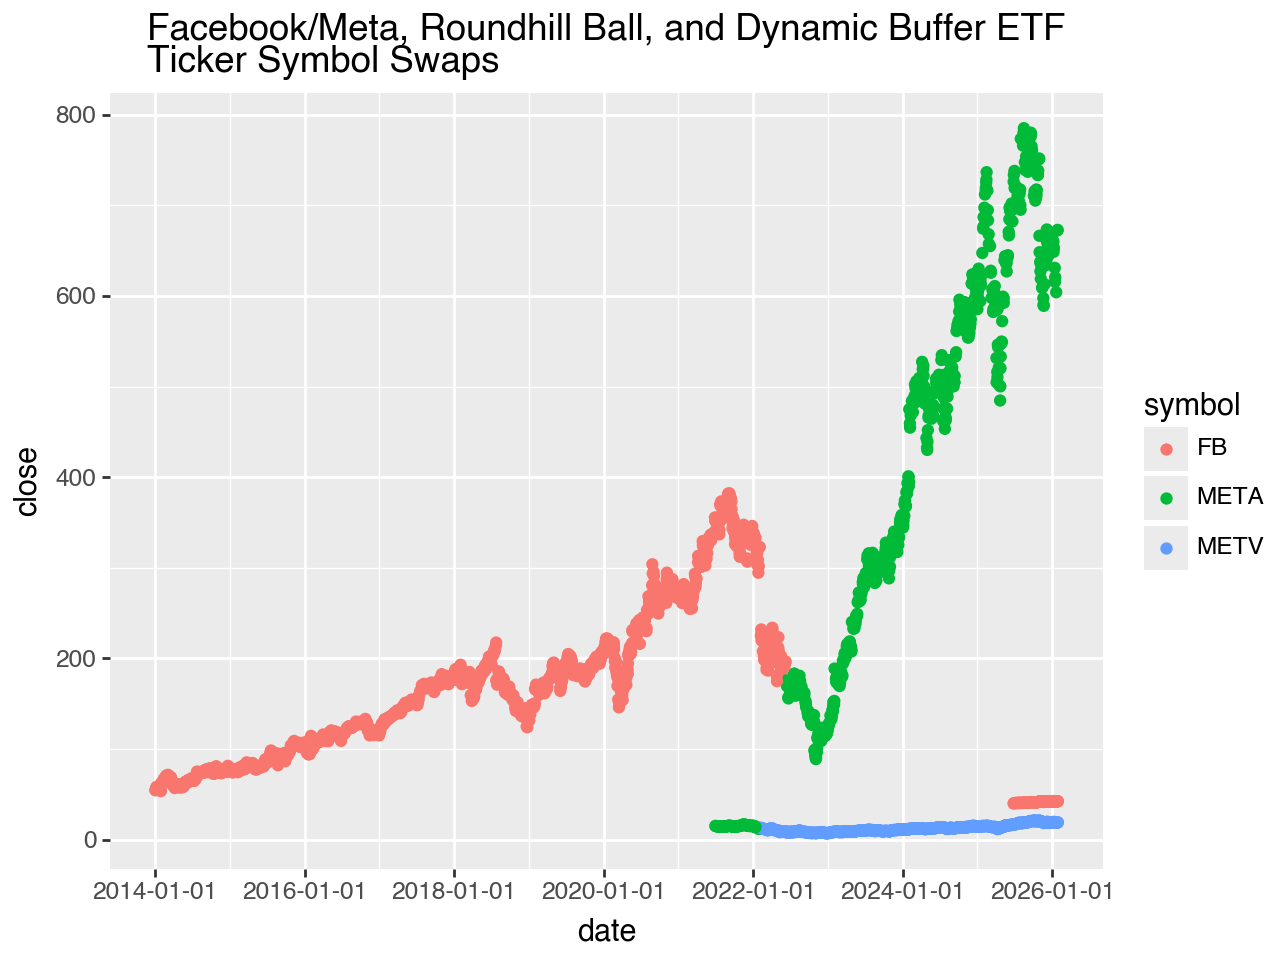

In [42]:
(
    p9.ggplot(some_eqs.loc[some_eqs.symbol.isin(('METV','META','FB'))], p9.aes(x='date', y='close', color='symbol'))
    + p9.geom_point()
    + p9.ggtitle("Facebook/Meta, Roundhill Ball, and Dynamic Buffer ETF\nTicker Symbol Swaps")
)

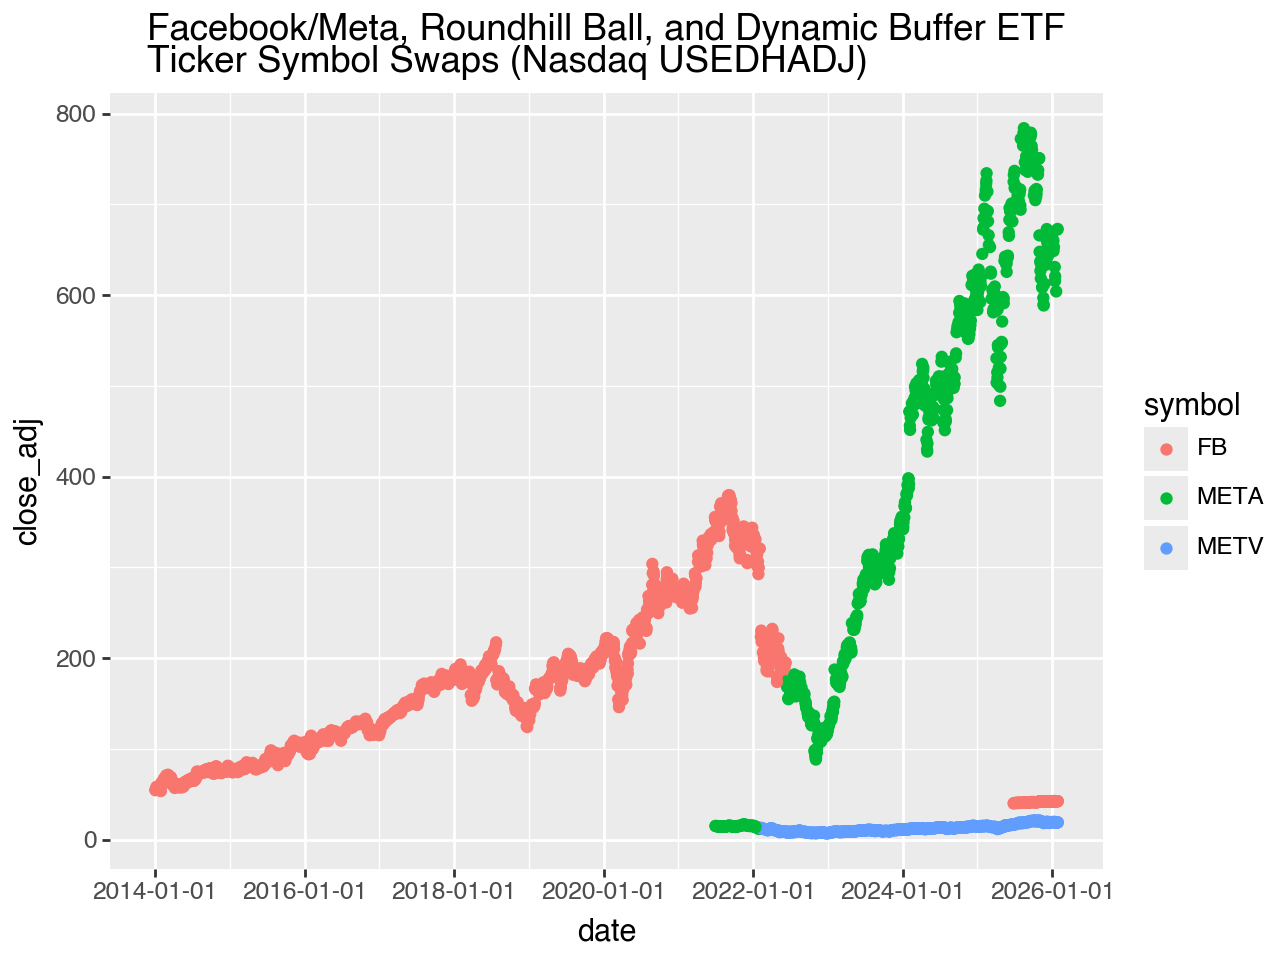

In [45]:
plt = (
    p9.ggplot(some_eqs.loc[some_eqs.symbol.isin(('METV','META','FB'))], p9.aes(x='date', y='close_adj', color='symbol'))
    + p9.geom_point()
    + p9.ggtitle("Facebook/Meta, Roundhill Ball, and Dynamic Buffer ETF\nTicker Symbol Swaps (Nasdaq USEDHADJ)")
)
plt

In [46]:
plt.save('/Users/brian/teach/33150/tex/Graph_FacebookTickerChanges.pdf')

## Download All Data Using Tables API (~2GB Of Disk Space, 4GB Of RAM)

In [5]:
def grab_nasdaq_table(
    table_path,
    avoid_download=False,
    replace_existing=False,
    date_override=None,
    allow_old_file=False,
    **kwargs,
):
    root_data_dir = os.path.join(os.environ["HOME"], "teach/teach_data", "nasdaq_data_table_downloads")
    data_symlink = os.path.join(root_data_dir, f"{table_path}_latest.zip")
    if avoid_download and os.path.exists(data_symlink):
        print(f"Skipping any possible download of {table_path}")
        return data_symlink
    
    table_dir = os.path.dirname(data_symlink)
    if not os.path.isdir(table_dir):
        print(f'Creating new data dir {table_dir}')
        os.mkdir(table_dir)

    if date_override is None:
        my_date = datetime.datetime.now().strftime("%Y%m%d")
    else:
        my_date = date_override
    data_file = os.path.join(root_data_dir, f"{table_path}_{my_date}.zip")

    if os.path.exists(data_file):
        file_size = os.stat(data_file).st_size
        if replace_existing or not file_size > 0:
            print(f"Removing old file {data_file} size {file_size}")
        else:
            print(
                f"Data file {data_file} size {file_size} exists already, no need to download"
            )
            return data_file

    dl = nasdaqdatalink.export_table(
        table_path, filename=data_file, **kwargs
    )
    file_size = os.stat(data_file).st_size
    if os.path.exists(data_file) and file_size > 0:
        print(f"Download finished: {file_size} bytes")
        if not date_override:
            if os.path.exists(data_symlink):
                print(f"Removing old symlink")
                os.unlink(data_symlink)
            print(f"Creating symlink: {data_file} -> {data_symlink}")
            os.symlink(
                data_file, data_symlink,
            )
    else:
        print(f"Data file {data_file} failed download")
        return
    return data_symlink if (date_override is None or allow_old_file) else "NoFileAvailable"


def fetch_nasdaq_table(table_path, avoid_download=True, **kwargs):
    return pd.read_csv(
        grab_nasdaq_table(table_path, avoid_download=avoid_download, **kwargs)
    )




In [6]:
nasdaq_tickers = fetch_nasdaq_table('NDAQ/TICKERS', avoid_download=False)
nasdaq_tickers.head()

Data file /Users/brian/teach/teach_data/nasdaq_data_table_downloads/NDAQ/TICKERS_20260129.zip size 266686 exists already, no need to download


,symbol,exchange,company_name
0,ATHA,NASDAQ,ATHIRA PHARMA INC
1,EPWK,NASDAQ,EPWK HOLDINGS LTD
2,IVP,NASDAQ,INSPIRE VETERINARY PARTNERS INC
3,FPAY,NASDAQ,FLEXSHOPPER INC
4,OP,NASDAQ,OCEANPAL INC


In [7]:
# 1.2GB nad about 10 minutes of download time on UChicago Wifi

adj_prices = fetch_nasdaq_table('NDAQ/USEDHADJ', avoid_download=False)

Fetching URL: https://data.nasdaq.com/api/v3/datatables/NDAQ/USEDHADJ.json with options: {'params': {'qopts.export': 'true'}, 'headers': {'x-api-token': 'xQJNSUnDfncqTKyakafQ', 'accept': 'application/json', 'request-source': 'python', 'request-source-version': '1.0.4'}}
Fetching URL: https://data.nasdaq.com/api/v3/datatables/NDAQ/USEDHADJ.json with options: {'params': {'qopts.export': 'true'}, 'headers': {'x-api-token': 'xQJNSUnDfncqTKyakafQ', 'accept': 'application/json', 'request-source': 'python', 'request-source-version': '1.0.4'}}
Fetching URL: https://data.nasdaq.com/api/v3/datatables/NDAQ/USEDHADJ.json with options: {'params': {'qopts.export': 'true'}, 'headers': {'x-api-token': 'xQJNSUnDfncqTKyakafQ', 'accept': 'application/json', 'request-source': 'python', 'request-source-version': '1.0.4'}}
Fetching URL: https://data.nasdaq.com/api/v3/datatables/NDAQ/USEDHADJ.json with options: {'params': {'qopts.export': 'true'}, 'headers': {'x-api-token': 'xQJNSUnDfncqTKyakafQ', 'accept': 

Fetching URL: https://data.nasdaq.com/api/v3/datatables/NDAQ/USEDHADJ.json with options: {'params': {'qopts.export': 'true'}, 'headers': {'x-api-token': 'xQJNSUnDfncqTKyakafQ', 'accept': 'application/json', 'request-source': 'python', 'request-source-version': '1.0.4'}}
Fetching URL: https://data.nasdaq.com/api/v3/datatables/NDAQ/USEDHADJ.json with options: {'params': {'qopts.export': 'true'}, 'headers': {'x-api-token': 'xQJNSUnDfncqTKyakafQ', 'accept': 'application/json', 'request-source': 'python', 'request-source-version': '1.0.4'}}
Fetching URL: https://data.nasdaq.com/api/v3/datatables/NDAQ/USEDHADJ.json with options: {'params': {'qopts.export': 'true'}, 'headers': {'x-api-token': 'xQJNSUnDfncqTKyakafQ', 'accept': 'application/json', 'request-source': 'python', 'request-source-version': '1.0.4'}}
Fetching URL: https://data.nasdaq.com/api/v3/datatables/NDAQ/USEDHADJ.json with options: {'params': {'qopts.export': 'true'}, 'headers': {'x-api-token': 'xQJNSUnDfncqTKyakafQ', 'accept': 

limit_output extension: Maximum message size of 10000 exceeded with 10027 characters

In [8]:
adj_prices.iloc[[0,1,2,1000000, 1000001,19000001,19000002,-3,-2,-1],:]

,date,symbol,symbol_new,composite_figi,share_class_figi,volume,low,high,open,close,volume_adj,low_adj,high_adj,open_adj,close_adj,action,value
0,2015-06-10,AA$,NaN,NaN,NaN,1949.0,85.0000,89.0000,89.0000,85.0000,1949.0,85.0000,89.0000,89.0000,85.0000,NaN,NaN
1,2015-06-10,AA$B,NaN,NaN,NaN,72425.0,43.5600,44.2300,44.2300,43.8499,72425.0,43.5600,44.2300,44.2300,43.8499,NaN,NaN
2,2015-06-10,AA-,NaN,NaN,NaN,1949.0,85.0000,89.0000,89.0000,85.0000,1949.0,85.0000,89.0000,89.0000,85.0000,NaN,NaN
1000000,2017-11-06,YMLP,NaN,NaN,NaN,6607.0,23.9000,24.0500,23.9000,24.0500,6607.0,23.9000,24.0500,23.9000,24.0500,NaN,NaN
1000001,2017-11-06,YNGFF,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN
19000001,2016-10-05,SCUPF,NaN,BBG000R4HYW3,BBG001SN5ST8,100.0,1.8712,1.8712,1.8712,1.8712,100.0,1.8712,1.8712,1.8712,1.8712,NaN,NaN
19000002,2017-05-26,SCUPF,NaN,BBG000R4HYW3,BBG001SN5ST8,25.0,NaN,NaN,NaN,NaN,25.0,NaN,NaN,NaN,NaN,NaN,NaN
46656167,2023-01-20,ZYNE,ZYNE,BBG007BBS8B7,BBG007BBS8C6,249599.0,0.5700,0.6072,0.5900,0.5900,249599.0,0.5700,0.6072,0.5900,0.5900,NaN,NaN
46656168,2023-06-26,ZYNE,ZYNE,BBG007BBS8B7,BBG007BBS8C6,211730.0,0.3300,0.3459,0.3318,0.3415,211730.0,0.3300,0.3459,0.3318,0.3415,NaN,NaN
46656169,2026-01-02,ZYXIQ,ZYXIQ,BBG000BJBXZ2,BBG001S7T7V0,395982.0,0.0900,0.1260,0.1139,0.0951,395982.0,0.0900,0.1260,0.1139,0.0951,NaN,NaN


In [9]:
adj_prices['date'].min(), adj_prices['date'].max()

('2014-01-02', '2026-01-28')

In [10]:
adj_prices['Date'] = pd.to_datetime(adj_prices['date'])

In [11]:
# Adj Close Only, Only Some Tickers and Dates, In Columns
tgt_tickers = ['JPM', 'SUN', 'IBM', 'TSM', 'PTLO']
pd.pivot_table(
    adj_prices.loc[
        (adj_prices['symbol'].isin(tgt_tickers))
        & (adj_prices['Date'].dt.weekday == 2)
    ][['Date','symbol','close_adj']],
    index='Date', columns='symbol',values='close_adj'
).sort_index().iloc[[0,1,2,-300,-299,-298,-3,-2,-1]]

symbol,IBM,JPM,PTLO,SUN,TSM
Date,,,,,
2014-01-08,110.929,42.659,NaN,NaN,12.680
2014-01-15,110.793,43.108,NaN,NaN,13.044
2014-01-22,107.554,41.731,NaN,NaN,13.341
2020-04-15,88.449,77.874,NaN,11.970,44.892
2020-04-22,88.911,76.630,NaN,14.468,47.866
2020-04-29,95.901,83.938,NaN,15.560,49.249
2026-01-14,309.030,307.870,5.45,57.630,327.110
2026-01-21,297.540,302.040,5.94,57.290,326.120
2026-01-28,294.160,300.770,5.63,58.440,342.300


In [12]:
tqqq = pd.pivot_table(
    adj_prices.loc[
        (adj_prices['symbol']=='TQQQ')
    ][['Date','symbol','close_adj']],
    index='Date', columns='symbol',values='close_adj'
).sort_index()#
tqqq.iloc[[0,1,2,-300,-299,-298,-3,-2,-1]]

symbol,TQQQ
Date,
2014-01-02,1.204
2014-01-03,1.178
2014-01-06,1.165
2024-11-14,39.567
2024-11-15,36.705
2024-11-18,37.447
2026-01-26,55.080
2026-01-27,56.540
2026-01-28,57.060


In [13]:
tqqq.index[0].__class__

pandas._libs.tslibs.timestamps.Timestamp

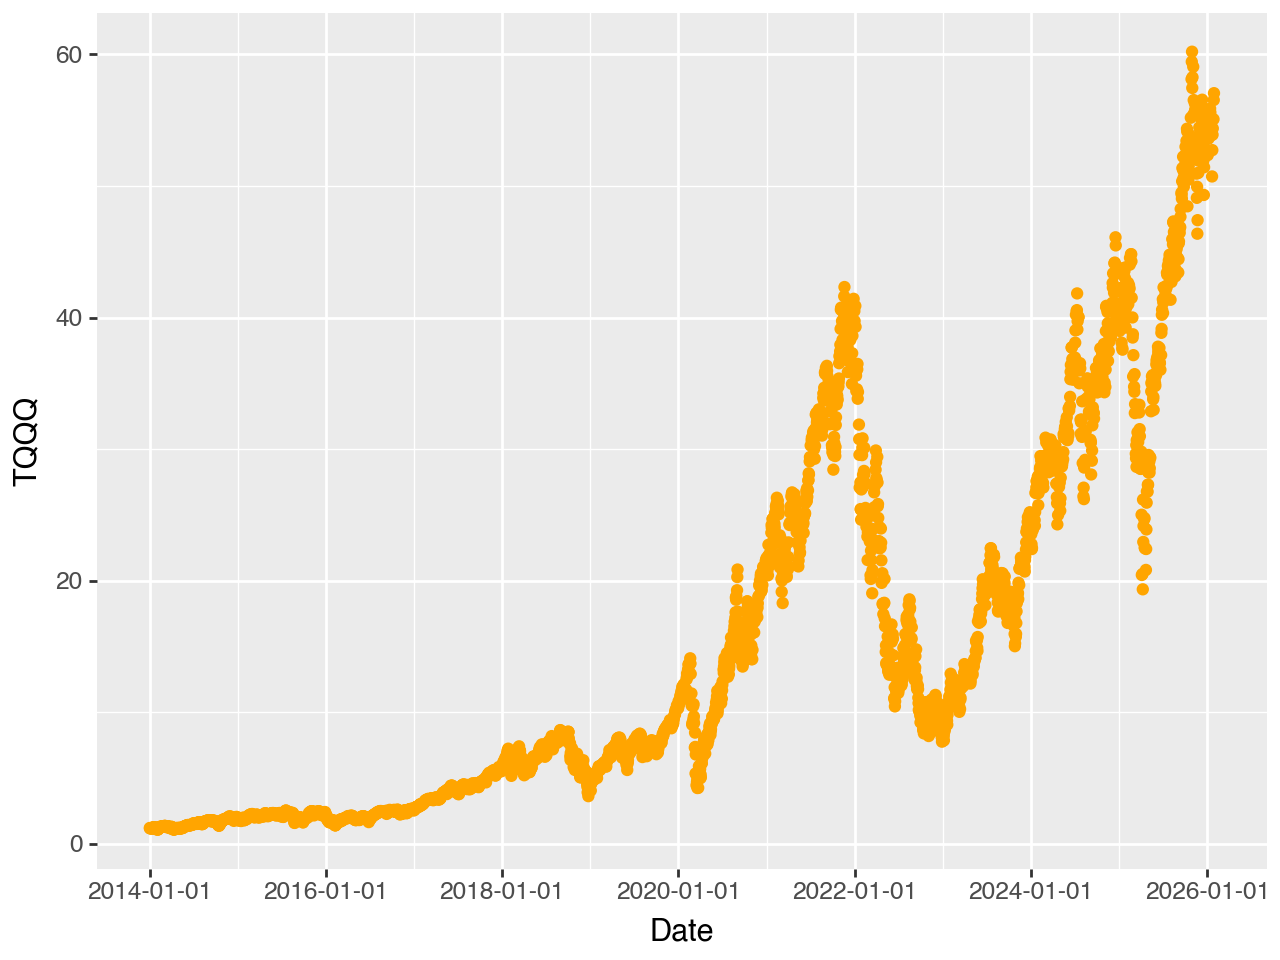

In [14]:
(
    p9.ggplot(tqqq.reset_index(), p9.aes(x='Date', y='TQQQ'))
    + p9.geom_point(color='orange')
)